In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [153]:
data = pd.read_csv("TemperatureDataSet.csv")

In [154]:
data.head()

,dt,AverageTemperature,AverageTemperatureUncertainty,Country
0,1743-11-01,4.384,2.294,Åland
1,1743-12-01,NaN,NaN,Åland
2,1744-01-01,NaN,NaN,Åland
3,1744-02-01,NaN,NaN,Åland
4,1744-03-01,NaN,NaN,Åland


In [155]:
data["Country"].nunique()

243

In [156]:
data = data.dropna()

In [157]:
data.head()

,dt,AverageTemperature,AverageTemperatureUncertainty,Country
0,1743-11-01,4.384,2.294,Åland
5,1744-04-01,1.530,4.680,Åland
6,1744-05-01,6.702,1.789,Åland
7,1744-06-01,11.609,1.577,Åland
8,1744-07-01,15.342,1.410,Åland


In [158]:
data[["year", "month", "day"]] = data.dt.str.split("-", expand = True)

In [159]:
data = data.drop(columns = ["Country", "AverageTemperatureUncertainty", "month", "day", "dt"])

In [160]:
data = data.drop_duplicates(subset = ["year"])

In [161]:
X = data
Y = data["AverageTemperature"]
X = X.drop(columns = ["AverageTemperature"])

In [162]:
X = X.to_numpy()
Y = Y.to_numpy()

In [163]:
print(X, Y)

[['1743']
 ['1744']
 ['1745']
 ['1750']
 ['1751']
 ['1752']
 ['1753']
 ['1754']
 ['1755']
 ['1756']
 ['1757']
 ['1758']
 ['1759']
 ['1760']
 ['1761']
 ['1762']
 ['1763']
 ['1764']
 ['1765']
 ['1766']
 ['1767']
 ['1768']
 ['1769']
 ['1770']
 ['1771']
 ['1772']
 ['1773']
 ['1774']
 ['1775']
 ['1776']
 ['1777']
 ['1778']
 ['1779']
 ['1780']
 ['1781']
 ['1782']
 ['1783']
 ['1784']
 ['1785']
 ['1786']
 ['1787']
 ['1788']
 ['1789']
 ['1790']
 ['1791']
 ['1792']
 ['1793']
 ['1794']
 ['1795']
 ['1796']
 ['1797']
 ['1798']
 ['1799']
 ['1800']
 ['1801']
 ['1802']
 ['1803']
 ['1804']
 ['1805']
 ['1806']
 ['1807']
 ['1808']
 ['1809']
 ['1810']
 ['1811']
 ['1812']
 ['1813']
 ['1814']
 ['1815']
 ['1816']
 ['1817']
 ['1818']
 ['1819']
 ['1820']
 ['1821']
 ['1822']
 ['1823']
 ['1824']
 ['1825']
 ['1826']
 ['1827']
 ['1828']
 ['1829']
 ['1830']
 ['1831']
 ['1832']
 ['1833']
 ['1834']
 ['1835']
 ['1836']
 ['1837']
 ['1838']
 ['1839']
 ['1840']
 ['1841']
 ['1842']
 ['1843']
 ['1844']
 ['1845']
 ['1846']


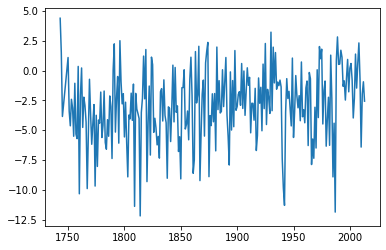

In [196]:
plt.plot(X[:,0].astype("int"), Y)
plt.show()

In [165]:
X_Train, X_Test, Y_Train, Y_Test = train_test_split(X, Y)

In [166]:
#Using Sklearn

In [167]:
print(X_Train.shape, Y_Train.shape, X_Test.shape, Y_Test.shape)

(200, 1) (200,) (67, 1) (67,)


In [168]:
X_Train, X_Test = X_Train.astype("int"), X_Test.astype("int")

In [169]:
regression = LinearRegression().fit(X_Train, Y_Train)

In [170]:
regression.score(X_Train, Y_Train)

0.023565133350889944

In [171]:
Y_Predicted_Train = regression.predict(X_Train)

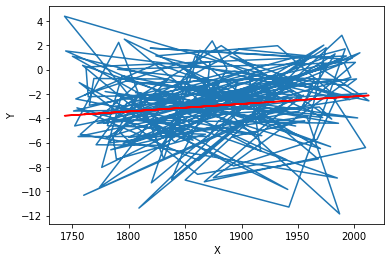

In [172]:
plt.plot(X_Train[:,0], Y_Train, label = 'Training Data')
plt.plot(X_Train[:,0], Y_Predicted_Train, 'r-', label = 'Predicted Line')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

In [173]:
Y_Predicted_Test = regression.predict(X_Test)

In [174]:
regression.score(X_Test, Y_Test)

0.08352313396171618

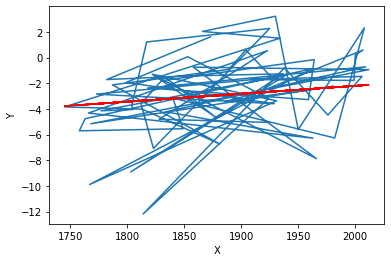

In [175]:
plt.plot(X_Test[:,0], Y_Test, label = 'Testing Data')
plt.plot(X_Test[:,0], Y_Predicted_Test, 'r-', label = 'Predicted Line')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

In [176]:
#From scratch

In [188]:
X_Train_Normalized = (X_Train - np.mean(X_Train)) / np.std(X_Train)
print(X_Train_Normalized)

[[ 0.43828528]
 [-1.10776329]
 [-1.27665935]
 [-0.328243  ]
 [-1.02981126]
 [-0.43217904]
 [ 0.28238122]
 [ 0.30836523]
 [-0.76997116]
 [-0.26328298]
 [ 1.15284555]
 [-0.0554109 ]
 [ 1.50362968]
 [ 0.84103743]
 [-0.92587522]
 [-1.58846747]
 [ 1.37370963]
 [-0.45816305]
 [-0.56209909]
 [ 1.71150175]
 [-1.18571532]
 [ 0.80206142]
 [-0.88689921]
 [ 0.34734125]
 [ 0.4902533 ]
 [ 0.16545318]
 [ 0.99694149]
 [ 0.60718134]
 [-0.15934694]
 [ 1.69850975]
 [ 1.26977359]
 [ 0.68513337]
 [-0.71800315]
 [ 1.36071762]
 [ 1.13985354]
 [ 0.17844519]
 [-1.60145947]
 [-0.23729897]
 [ 0.78906941]
 [-0.48414706]
 [ 1.28276559]
 [ 1.62055772]
 [ 0.36033325]
 [-0.53611508]
 [-0.40619503]
 [ 0.10049316]
 [-0.06840291]
 [-1.36760338]
 [ 0.51623731]
 [-0.52312307]
 [-0.315251  ]
 [ 1.21780557]
 [-0.00344288]
 [-0.10737892]
 [-1.61445148]
 [ 0.86702144]
 [-0.41918703]
 [-0.0424189 ]
 [-1.12075529]
 [-1.34161938]
 [ 0.11348516]
 [ 1.20481356]
 [ 0.4772613 ]
 [-1.65342749]
 [-1.1467393 ]
 [-0.62705911]
 [-0.21131

In [207]:
X_Test_Normalized = (X_Test - np.mean(X_Test)) / np.std(X_Test)
print(X_Test_Normalized)

[[ 0.51485888]
 [-0.69551112]
 [ 0.52773516]
 [-1.49384027]
 [ 1.04278622]
 [-0.61825346]
 [ 1.63509495]
 [-0.82427389]
 [ 0.99128111]
 [ 1.0556625 ]
 [-0.64400601]
 [ 1.08141505]
 [-0.30922282]
 [ 1.67372377]
 [-1.46808772]
 [ 1.2745592 ]
 [ 0.05131292]
 [ 0.41184867]
 [ 1.60934239]
 [ 1.51920846]
 [ 1.50633218]
 [ 0.33459101]
 [ 1.59646612]
 [ 1.21017782]
 [ 0.72087931]
 [-0.87577899]
 [ 0.54061143]
 [-0.3736042 ]
 [-1.06892314]
 [ 0.60499282]
 [-1.40370633]
 [ 0.57924026]
 [ 0.2830859 ]
 [ 0.08994175]
 [-1.22343846]
 [-0.01306846]
 [-0.88865527]
 [-1.76424208]
 [ 0.6693742 ]
 [-0.20621261]
 [ 0.61786909]
 [ 0.87539463]
 [ 1.62221867]
 [ 1.28743548]
 [-0.5409958 ]
 [-0.42510931]
 [-1.59685048]
 [-1.5324691 ]
 [ 1.02990994]
 [-1.48096399]
 [ 0.63074537]
 [-0.77276878]
 [-0.06457357]
 [-0.63112974]
 [-0.90153155]
 [-0.7598925 ]
 [ 0.55348771]
 [-0.83715016]
 [-1.00454176]
 [-0.99166548]
 [-1.35220123]
 [ 0.73375558]
 [-1.01741803]
 [ 0.70800303]
 [-0.39935676]
 [-1.28781984]
 [-0.11607

In [200]:
def costFunc(w1, b, X, Y):
    J = 0
    m, n = X.shape
    for i in range(m):
        f_x = w1 * X[i] + b
        J += (f_x - Y[i]) ** 2
    J = ((1 / (2 * m)) * J)
    return J

In [215]:
def predict(w1, b, X, Y):
    J = 0
    m, n = X.shape
    pred = []
    for i in range(m):
        f_x = w1 * X[i] + b
        pred.append(f_x)
    return pred

In [201]:
def computeGradient(w1, b, X, Y):
    m, n = X.shape
    dJ_dw_1 = 0
    dJ_db = 0
    for i in range(m):
        f_x = w1 * X[i] + b
        dJ_dw_1 += (f_x - Y[i]) * X[i]
        dJ_db += (f_x - Y[i])
    dJ_dw_1 = ((1 / m) * dJ_dw_1)
    dJ_db = (1 / m) * dJ_db
    return dJ_dw_1, dJ_db

In [204]:
def gradientDes(alpha, iterations, w1, b, X, Y):
    for i in range(iterations):
        dJ_dw_1, dJ_db = computeGradient(w1, b, X, Y)
        w1 = w1 - alpha * dJ_dw_1
        b = b - alpha * dJ_db
        if i % 10 == 0:
            J = costFunc(w1, b, X, Y)
            print("At iteration", i, " Cost is ", J.shape[0])
    return w1, b

In [205]:
w, b = gradientDes(0.01, 100, 1, 3, X_Train_Normalized, Y_Train)
print("Optimal values of w and b are ", w, b)

At iteration 0  Cost is  1
At iteration 10  Cost is  1
At iteration 20  Cost is  1
At iteration 30  Cost is  1
At iteration 40  Cost is  1
At iteration 50  Cost is  1
At iteration 60  Cost is  1
At iteration 70  Cost is  1
At iteration 80  Cost is  1
At iteration 90  Cost is  1
Optimal values of w and b are  [0.66765765] [-0.7730395]


In [216]:
Y_Test_Pred = predict(w, b, X_Test_Normalized, Y_Test)

In [219]:
for i in range(len(Y_Test_Pred)):
    print(Y_Test_Pred[i][0], ",", Y_Test[i])

-0.4292900323045776 , -5.05
-1.237402820435394 , -4.808999999999998
-0.42069308774999437 , 0.5390000000000001
-1.7704133828195494 , -4.324999999999998
-0.07681530556666827 , -6.287999999999999
-1.185821153107895 , -4.23
0.31864414394415663 , -0.7249999999999996
-1.3233722659812255 , -2.372
-0.11120308378500088 , -3.28
-0.06821836101208523 , -0.1639999999999997
-1.2030150422170613 , -1.779
-0.05102447190291892 , -7.879
-0.9794944837978993 , -0.7489999999999997
0.3444349776079062 , -0.9429999999999998
-1.7532194937103829 , -5.159
0.07792969641582836 , -2.24
-0.738780036269571 , -3.427
-0.4980655887412428 , -2.755
0.3014502548349903 , 0.5939999999999999
0.24127164295290837 , 0.197
0.2326746983983251 , -1.7839999999999998
-0.5496472560687417 , -1.713
0.2928533102804073 , -1.4719999999999998
0.03494497364291271 , -4.48
-0.29173891943124713 , -0.8019999999999996
-1.357760044199558 , -12.187
-0.41209614319541127 , -3.1910000000000003
-1.022479206570815 , 0.0630000000000001
-1.4867142125183053

In [220]:
#RESULT

In [ ]:
#From the above graphs, it is quite clear that a straight line cannot be a good estimator of the dataset.
#A higher order polynomial would be much better. There are outliers and Linear Regression fails here